In [1]:
from google.colab import files
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# Upload 'bird_small.mat'
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

# Load image data
data = sio.loadmat(filename)
A = data['A']
print("Original image shape:", A.shape)

# Normalize pixel values to [0,1]
A = A / 255.0

# Reshape to a 2D array (each row = one pixel, columns = RGB channels)
X = A.reshape(-1, 3)
print("Reshaped X:", X.shape)


Saving bird_small.mat to bird_small.mat
Uploaded file: bird_small.mat
Original image shape: (128, 128, 3)
Reshaped X: (16384, 3)


In [2]:
def init_centroids(X, K):
    """Randomly initialize K centroids from dataset."""
    random_indices = np.random.choice(X.shape[0], K, replace=False)
    return X[random_indices]

K = 16  # number of colors for compression
initial_centroids = init_centroids(X, K)
print("Initial centroids shape:", initial_centroids.shape)


Initial centroids shape: (16, 3)


In [3]:
def find_closest_centroids(X, centroids):
    m = X.shape[0]
    K = centroids.shape[0]
    idx = np.zeros(m, dtype=int)
    for i in range(m):
        distances = np.linalg.norm(X[i] - centroids, axis=1)
        idx[i] = np.argmin(distances)
    return idx

def compute_centroids(X, idx, K):
    n = X.shape[1]
    centroids = np.zeros((K, n))
    for k in range(K):
        points = X[idx == k]
        if len(points) > 0:
            centroids[k] = np.mean(points, axis=0)
    return centroids

def run_k_means(X, initial_centroids, max_iters=10):
    centroids = initial_centroids
    for i in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        centroids = compute_centroids(X, idx, centroids.shape[0])
    return centroids, idx


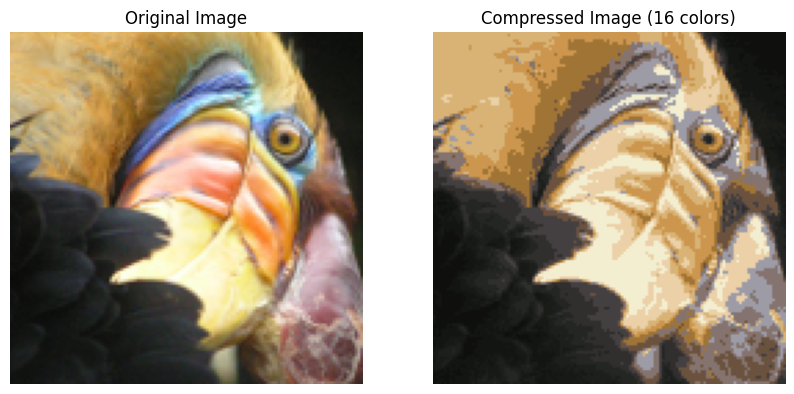

In [4]:
final_centroids, idx = run_k_means(X, initial_centroids, max_iters=10)

# Reconstruct the compressed image
X_compressed = final_centroids[idx]
X_compressed = X_compressed.reshape(A.shape)

# Display original vs compressed
fig, ax = plt.subplots(1, 2, figsize=(10,6))
ax[0].imshow(A)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(X_compressed)
ax[1].set_title(f'Compressed Image ({K} colors)')
ax[1].axis('off')
plt.show()


Saving ex7data2.mat to ex7data2.mat
Uploaded file: ex7data2.mat
Shape of X: (300, 2)


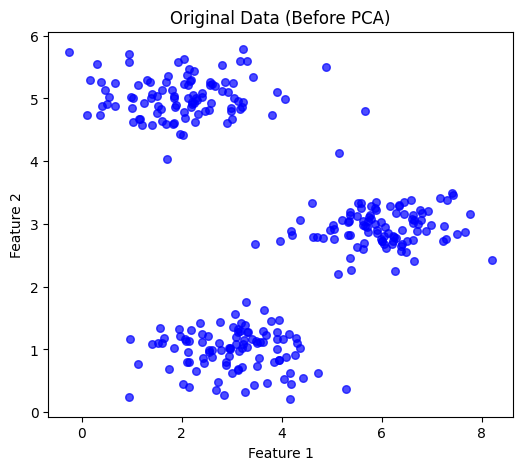

In [5]:
# Upload 'ex7data1.mat'
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

data = sio.loadmat(filename)
X = data['X']
print("Shape of X:", X.shape)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=30, c='blue', alpha=0.7)
plt.title("Original Data (Before PCA)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [6]:
def feature_normalize(X):
    mu = np.mean(X, axis=0)       # moyenne par colonne (feature)
    sigma = np.std(X, axis=0)     # écart-type par colonne
    X_norm = (X - mu) / sigma     # standardisation
    return X_norm, mu, sigma

X_norm, mu, sigma = feature_normalize(X)


In [7]:
# Compute covariance matrix
Sigma = (X_norm.T @ X_norm) / X_norm.shape[0]  # covariance matrix

# Compute SVD
U, S, Vt = np.linalg.svd(Sigma)


In [8]:
# Project data onto the first principal component
Z = X_norm @ U[:, 0:1]   # Projection (2D → 1D)

# Recover data (approximation inverse)
X_rec = Z @ U[:, 0:1].T
X_rec = X_rec * sigma + mu   # on remet les valeurs d’origine


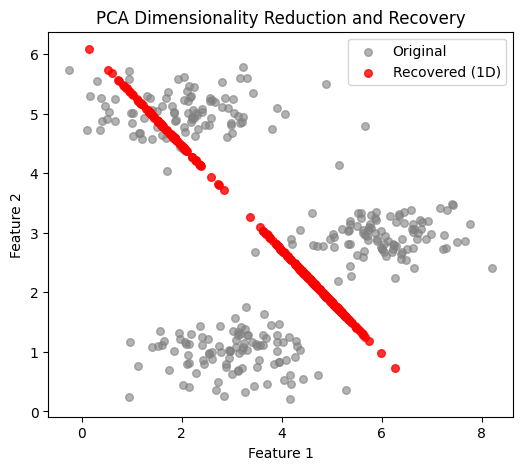

In [9]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=30, c='gray', alpha=0.6, label='Original')
plt.scatter(X_rec[:,0], X_rec[:,1], s=30, c='red', alpha=0.8, label='Recovered (1D)')
plt.legend()
plt.title("PCA Dimensionality Reduction and Recovery")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
